# 🏠 MietCheck · 🔁 QUA³CK-Phase 5: Kreuzvalidierung

**Modul:** Data Analytics & Big Data (IU, 4. Semester) · **Projekt:** MietCheck – „Zahle ich zu viel Miete?"

> Teil 5 von 6 der QUA³CK-Notebook-Serie. Reihenfolge:
> **Q**ualitätsprüfung → **U**nderstanding → **A**lgorithmenauswahl →
> Modellentwicklung → **C**ross-Validation → **K**nowledge.

**Ziel:** die Modelle *fair* vergleichen und das beste robust auswählen – mit 5-facher Kreuzvalidierung statt eines einzelnen Zufalls-Splits.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import config as C
sns.set_theme(style='whitegrid', palette='rocket')
print('Setup ok ·', ROOT.name)

Setup ok · MietCheck


## 1. Warum Kreuzvalidierung?
Ein einzelner Train/Test-Split kann Glück oder Pech sein. Bei **k-facher CV** wird das Modell k-mal auf verschiedenen Teilen trainiert/getestet → der gemittelte Fehler ist verlässlicher.

## 2. Ergebnisse der 5-fachen CV (aus `src/train.py`)

In [2]:
m = json.loads((C.REPORT_DIR/'metrics.json').read_text())
cv = pd.DataFrame(m['cv_results']).T[['cv_mae','cv_std']].round(1)
cv.columns = ['CV-MAE (€)','± Std']
cv.sort_values('CV-MAE (€)')

,CV-MAE (€),± Std
Gradient Boosting,90.2,0.6
Random Forest,102.7,0.8
Lineare Regression,120.5,0.7


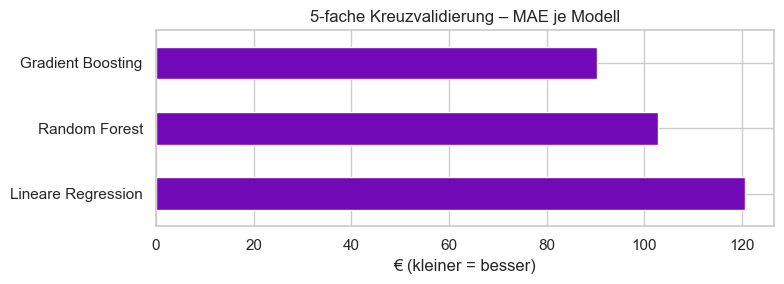

Bestes Modell: Gradient Boosting


In [3]:
ax = cv['CV-MAE (€)'].sort_values(ascending=False).plot.barh(figsize=(8,3), color='#7209b7')
ax.set(title='5-fache Kreuzvalidierung – MAE je Modell', xlabel='€ (kleiner = besser)')
plt.tight_layout(); plt.show()
print('Bestes Modell:', m['best_model'])

## 3. Live-Demonstration (kurze CV auf Stichprobe)
Zeigt den Mechanismus nachvollziehbar:

In [4]:
from sklearn.model_selection import cross_val_score
from train import build_preprocessor, get_models
df = pd.read_parquet(C.CLEAN_PARQUET).sample(20000, random_state=C.RANDOM_STATE)
gb = get_models(build_preprocessor())['Gradient Boosting']
sc = -cross_val_score(gb, df[C.FEATURES], df[C.TARGET], cv=5,
                      scoring='neg_mean_absolute_error')
print('MAE je Fold:', np.round(sc,1))
print(f'Mittelwert: {sc.mean():.1f} € (± {sc.std():.1f})')

MAE je Fold: [105.  105.7 104.1 103.  101.4]
Mittelwert: 103.9 € (± 1.5)


## 4. Endgültige Testgüte

In [5]:
print(f"Bestes Modell : {m['best_model']}")
print(f"Test-MAE      : {m['test_mae']} €")
print(f"Test-R²       : {m['test_r2']}")
print(f"Test-MAPE     : {m['test_mape']} %")

Bestes Modell : Gradient Boosting
Test-MAE      : 89.7 €
Test-R²       : 0.898
Test-MAPE     : 13.7 %


## ✅ Fazit Phase C
- **Gradient Boosting** gewinnt die Kreuzvalidierung klar (niedrigster CV-MAE).
- Auf dem unabhängigen Testset: **± ~90 € (R² ≈ 0,90)**.
- Die Auswahl ist robust, nicht vom Zufall eines Splits abhängig.

➡️ Weiter mit **06 · Wissensextraktion**.